# Wailau Landslide: Dispersive vs. Shallow-Water Tsunami Rays

The **Wailau Landslide** off the north flank of Moloka'i (Hawaiʻi) is a historical very
large submarine landslides (~1 200 km³), and a benchmark case for short-period tsunami
source physics.  Landslide-generated waves are characteristically **short**, the dominant
wavelength tracks the length scale of the sliding mass, not the ocean basin depth.

Here the slide's characteristic wavelength is taken as **λ = 15 km** (deep-water reference).
At this scale the full linear dispersion relation yields group speeds that are roughly *half*
the shallow-water approximation at typical mid-ocean depths, producing travel-time errors
of > 50 %.  This notebook:

1. Visualises the dispersive group-speed correction as a function of **period** and **wavelength**
   for ocean depths of 500 – 4 000 m.
2. Traces tsunami rays from the Wailau headwall under the **shallow-water** and
   **dispersive** wave speed models and maps the difference in first-arrival times.

> **Requires** `scipy` and `netCDF4`:  `pip install -e ".[examples]"`

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import TsunamiTrace as tt

## 1  Dispersion physics

### 1.1  Why the shallow-water approximation breaks down for landslide and volcanic sources

The familiar shallow-water wave speed $c = \sqrt{gh}$ is not a fundamental law; it is a limiting case of the full linear wave theory, valid only when the wavelength $\lambda$ is much longer than the water depth $h$. The relevant dimensionless parameter is $kh$, where $k = 2\pi/\lambda$ is the wavenumber. When $kh \ll 1$ the approximation is excellent; as $kh$ approaches and exceeds 1 it fails progressively.

For a megathrust earthquake the source length scale is hundreds of kilometres, so $kh$ is tiny and the shallow-water speed is accurate to well under 1 %. Landslide and volcanic sources are fundamentally different: their characteristic length scale is the size of the slide mass or eruption vent, typically 5–50 km. For the Wailau slide at $\lambda = 15$ km in 4 km of water:

$$kh = \frac{2\pi}{15\,\text{km}} \times 4\,\text{km} \approx 1.7$$

This puts the wave firmly in an intermediate regime (neither shallow-water nor deep-water) where the full dispersion relation (introduced in the next section) must be used. As the figures below show, the true wave speed at this scale is roughly half of $\sqrt{gh}$ at typical ocean depths, so ignoring dispersion would make predicted travel times too short by a factor of approximately two.

### 1.2  The full linear dispersion relation

Linear theory for surface gravity waves on a fluid of uniform depth $h$ yields the exact relationship between angular frequency $\omega$ (rad/s) and wavenumber $k$ (rad/m):

$$\omega^2 = g\,k\,\tanh(kh)$$

This **dispersion relation** comes from solving the Laplace equation for the velocity potential inside the fluid, with a kinematic condition at the free surface (the surface must move with the fluid) and a no-normal-flow condition at the flat bottom. The $\tanh(kh)$ factor captures the effect of the bottom: in deep water the bottom is so far away it has no influence ($\tanh(kh) \to 1$); in shallow water the bottom strongly constrains the flow ($\tanh(kh) \to kh$).

The three regimes in practice:

| Regime | Condition | $\tanh(kh)$ | Phase speed |
|--------|-----------|-------------|-------------|
| Shallow water | $kh \ll 1$ | $\approx kh$ | $\sqrt{gh}$: depth-controlled, independent of wavelength |
| Intermediate | $kh \sim 1$ | full expression | between the two limits |
| Deep water | $kh \gg 1$ | $\approx 1$ | $\sqrt{g/k}$: wavelength-controlled, independent of depth |

At $kh \approx 1.7$ the Wailau case has $\tanh(kh) \approx 0.94$, well off the shallow-water limit of $kh$ and already close to the deep-water limit of 1. This is why $\sqrt{gh}$ fails so badly here: the bottom is essentially invisible to the wave at this wavelength, and depth no longer controls the speed.

### 1.3  Phase speed vs. group speed

Two speeds describe a dispersive wave:

**Phase speed** $c_{\rm phase} = \omega / k$ is the speed at which individual wave crests advance. It is what you see watching a single crest move across the water surface.

**Group speed** $c_{\rm group} = d\omega/dk$ is the speed at which the wave *envelope* (the packet of energy) advances. In a dispersive medium, waves of slightly different frequencies travel at different phase speeds and the packet spreads out; the envelope moves at the group speed. Ray theory tracks the propagation of wave energy, so it must use the group speed, not the phase speed.

To derive $c_{\rm group}$, differentiate the dispersion relation with respect to $k$:

$$2\omega \frac{d\omega}{dk} = g\left[\tanh(kh) + \frac{kh}{\cosh^2(kh)}\right]$$

Rearranging and substituting $\omega^2 = g\,k\,\tanh(kh)$ to eliminate $g$ gives the result in a convenient form:

$$c_{\rm group} = \frac{c_{\rm phase}}{2}\left[1 + \frac{2kh}{\sinh(2kh)}\right]$$

The bracket lies between 2 (shallow water, $kh \to 0$, so $c_{\rm group} = c_{\rm phase} = \sqrt{gh}$) and 1 (deep water, $kh \to \infty$, so $c_{\rm group} = c_{\rm phase}/2$). For Wailau at 4 km depth the bracket is approximately 1.27, giving $c_{\rm group} \approx 0.44 \, c_{\rm phase}$.

### 1.4  Why $\omega$ is conserved along rays, but $k$ is not

When a wave crosses into a region of different depth, the wave must be continuous across the boundary: the same number of crests must arrive per second on both sides. Therefore frequency $\omega$ is conserved as the wave propagates across varying bathymetry. This is directly analogous to Snell's law for light, where the frequency (colour) is fixed by the source and does not change as light enters a new medium; only the wavelength changes.

Because $\omega$ is fixed and $\omega^2 = g\,k\,\tanh(kh)$ must hold at every point, the wavenumber $k$ adjusts to satisfy the relation at the local depth $h$. As the wave moves from deep to shallow water, $k$ increases (the wavelength shortens) and the group speed decreases: waves slow down and refract as they approach the coast. This depth-dependent refraction is exactly what the ray-tracing ODE captures.

### 1.5  From user input to local wave speed: finding $k$ at each grid cell

When you call `trace_rays(..., period=T)` or `trace_rays(..., wavelength=lam)`, the code converts your input to an angular frequency:

- Period $T$: $\quad \omega = 2\pi / T$
- Deep-water wavelength $\lambda$: $\quad \omega = \sqrt{g \cdot 2\pi/\lambda}$

This $\omega$ is then treated as a conserved property of the wave (Section 1.4) and used for every grid cell. But to actually compute the group speed at a cell, we need the local wavenumber $k$, because both $c_{\rm phase} = \omega/k$ and the bracket in the group speed formula depend on $k$ and $h$ (Sections 1.2 and 1.3). The user specified $\omega$, not $k$, and $k$ changes with depth.

At each grid cell with depth $h$ we must therefore find the $k$ that satisfies the dispersion relation for the given $\omega$:

$$\omega^2 = g\,k\,\tanh(kh)$$

This equation is **transcendental**: $k$ appears both as a linear factor and inside $\tanh(kh)$, so no algebraic closed form exists. We solve it with Newton-Raphson iteration, starting from the shallow-water guess $k_0 = \omega/\sqrt{gh}$ (which overestimates $k$ in intermediate and deep water, guaranteeing one-sided convergence):

$$k_{n+1} = k_n - \frac{F(k_n)}{F'(k_n)}, \qquad F(k) = \omega^2 - g\,k\,\tanh(kh), \qquad F'(k) = -g\left[\tanh(kh) + \frac{kh}{\cosh^2(kh)}\right]$$

This solve is performed across the entire bathymetry grid using NumPy array operations before any rays are traced, so all cells are updated simultaneously. Fifteen iterations drive the residual below machine precision for any physically realistic $kh$. The resulting group speed field replaces the $\sqrt{gh}$ field in the standard ray-tracing ODE.

---

TsunamiTrace handles all of the above internally. To use dispersive ray tracing you do not
need to solve any equations yourself; you just pass one extra argument to `trace_rays`:

```python
# by period (seconds)
tt.trace_rays(..., period=98)

# by frequency (Hz)
tt.trace_rays(..., frequency=1/98)

# by deep-water wavelength (metres)
tt.trace_rays(..., wavelength=15_000)
```

The code converts your input to $\omega$, solves the dispersion relation across the entire
bathymetry grid, builds the group speed field, and passes it to the RK4 integrator.
Everything else works exactly as in the shallow-water case.

The cells below are **illustrative only**: they use the same dispersion solver to plot how
group speed and the shallow-water error vary with period and wavelength at a few
representative ocean depths. If you want to skip straight to tracing rays and computing
travel times, jump ahead to Section 2.

In [2]:
_G = 9.8   # m/s²

def group_speed_grid(depths_1d, omega_1d, n_iter=15):
    """
    Dispersive group speed on a (n_depths × n_omega) grid.

    Parameters
    ----------
    depths_1d : array_like, shape (n_depths,)
    omega_1d  : array_like, shape (n_omega,)

    Returns
    -------
    c_group : ndarray, shape (n_depths, n_omega)
    """
    H     = np.asarray(depths_1d, float)[:, None]   # (n_depths, 1)
    OMEGA = np.asarray(omega_1d,  float)[None, :]   # (1, n_omega)

    k = OMEGA / np.sqrt(_G * H)   # shallow-water initial guess

    for _ in range(n_iter):
        kh      = np.minimum(k * H, 500.0)
        tanh_kh = np.tanh(kh)
        sech2   = np.zeros_like(kh)
        m       = kh < 355.0
        sech2[m] = 1.0 / np.cosh(kh[m]) ** 2
        F  = OMEGA ** 2 - _G * k * tanh_kh
        dF = -_G * (tanh_kh + k * H * sech2)
        k  = np.maximum(k - F / dF, 1e-10)

    kh      = k * H
    c_phase = OMEGA / k
    two_kh  = 2.0 * kh
    ratio   = np.where(two_kh < 1e-6, 1.0,
                       two_kh / np.sinh(np.minimum(two_kh, 500.0)))
    return 0.5 * c_phase * (1.0 + ratio)


DEPTHS = [500, 1000, 2000, 4000]                       # representative depths (m)
COLORS = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']  # blue, orange, green, red

# ── Wailau characteristic parameters ─────────────────────────────────────────
LAM_WAILAU   = 15_000                       # deep-water wavelength, m
K_DEEP_W     = 2 * np.pi / LAM_WAILAU      # deep-water wavenumber, rad/m
OMEGA_WAILAU = np.sqrt(_G * K_DEEP_W)      # angular frequency (conserved along rays)
T_WAILAU     = 2 * np.pi / OMEGA_WAILAU    # period, s

print(f"Wailau:  λ_deep = {LAM_WAILAU/1000:.0f} km")
print(f"         ω      = {OMEGA_WAILAU:.5f} rad/s")
print(f"         T      = {T_WAILAU:.1f} s  =  {T_WAILAU/60:.2f} min")

# Group speed at each depth for the Wailau frequency
c_sw_depths = np.array([np.sqrt(_G * h) for h in DEPTHS])
c_g_depths  = group_speed_grid(DEPTHS, [OMEGA_WAILAU])[:, 0]
print()
print(f"{'Depth (m)':>12}  {'c_SW (m/s)':>12}  {'c_group (m/s)':>14}  {'SW error (%)':>13}")
for h, csw, cg in zip(DEPTHS, c_sw_depths, c_g_depths):
    print(f"{h:>12}  {csw:>12.1f}  {cg:>14.1f}  {(csw-cg)/csw*100:>13.1f}")

Wailau:  λ_deep = 15 km
         ω      = 0.06407 rad/s
         T      = 98.1 s  =  1.63 min

   Depth (m)    c_SW (m/s)   c_group (m/s)   SW error (%)
         500          70.0            63.0           10.0
        1000          99.0            80.0           19.2
        2000         140.0            91.2           34.9
        4000         198.0            86.9           56.1


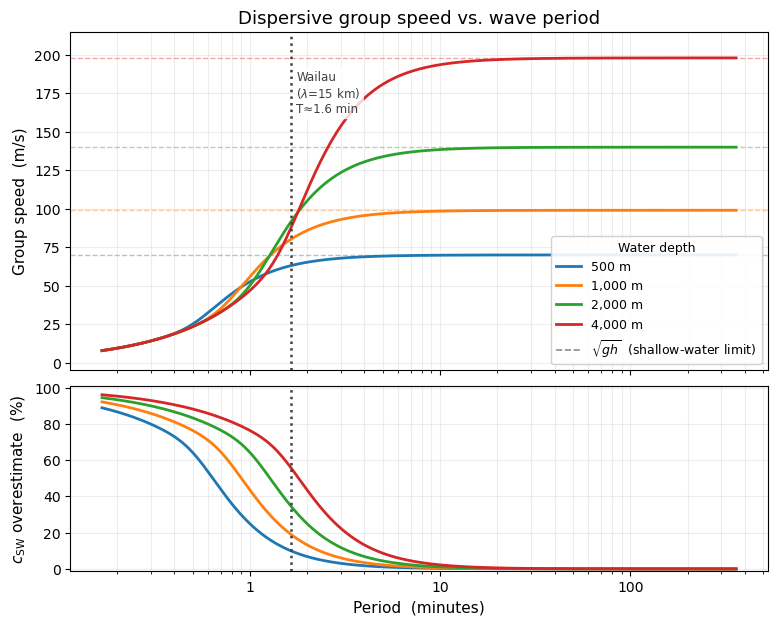

In [3]:
periods  = np.logspace(np.log10(10), np.log10(6 * 3600), 600)   # 10 s → 6 h
omega_T  = 2 * np.pi / periods                                   # (n_periods,)

c_g_T = group_speed_grid(DEPTHS, omega_T)                  # (n_depths, n_periods)
c_sw  = np.array([np.sqrt(_G * h) for h in DEPTHS])        # (n_depths,)

fig, (ax_s, ax_e) = plt.subplots(
    2, 1, figsize=(9, 7), sharex=True,
    gridspec_kw={'height_ratios': [2.2, 1.2], 'hspace': 0.06}
)

for i, (h, col) in enumerate(zip(DEPTHS, COLORS)):
    ax_s.plot(periods / 60, c_g_T[i], color=col, lw=2, label=f'{h:,} m')
    ax_s.axhline(c_sw[i], color=col, lw=1, ls='--', alpha=0.4)
    ax_e.plot(periods / 60, (c_sw[i] - c_g_T[i]) / c_sw[i] * 100, color=col, lw=2)

# SW legend dummy entry
ax_s.plot([], [], 'k--', lw=1.2, alpha=0.45, label=r'$\sqrt{gh}$  (shallow-water limit)')

# Wailau vertical marker
for ax in (ax_s, ax_e):
    ax.axvline(T_WAILAU / 60, color='0.25', ls=':', lw=1.8, zorder=4)
ax_s.text(T_WAILAU / 60 * 1.07, 190,
          f'Wailau\n($\lambda$=15 km)\nT≈{T_WAILAU/60:.1f} min',
          fontsize=8.5, va='top', ha='left', color='0.25',
          bbox=dict(boxstyle='round,pad=0.3', fc='white', alpha=0.8, ec='none'))

ax_s.set_xscale('log')
ax_s.set_ylim(-5, 215)
ax_s.set_ylabel('Group speed  (m/s)', fontsize=11)
ax_s.set_title('Dispersive group speed vs. wave period', fontsize=13)
ax_s.legend(title='Water depth', fontsize=9, title_fontsize=9,
            loc='lower right', framealpha=0.9)
ax_s.grid(True, which='both', alpha=0.22)

ax_e.set_ylim(bottom=-1)
ax_e.set_ylabel(r'$c_{\rm SW}$ overestimate  (%)', fontsize=11)
ax_e.set_xlabel('Period  (minutes)', fontsize=11)
ax_e.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{x:g}'))
ax_e.grid(True, which='both', alpha=0.22)

plt.show()

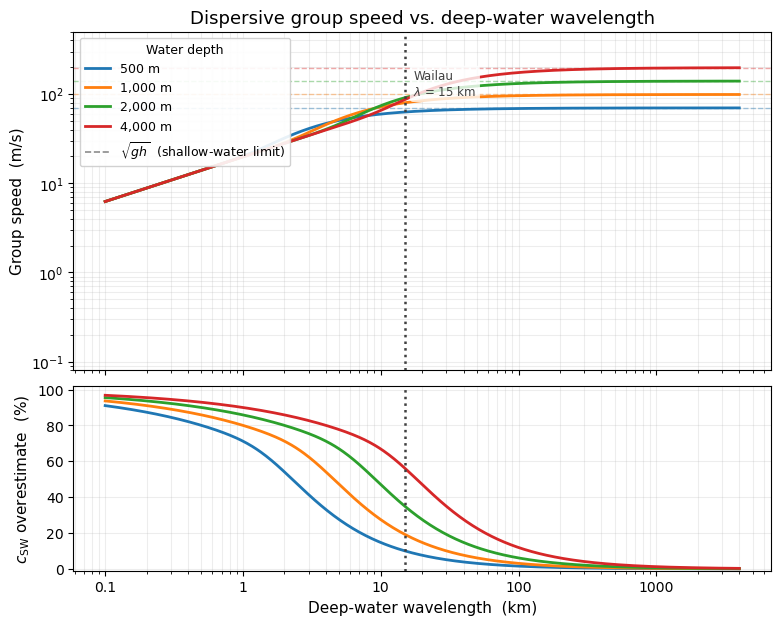

In [4]:
# For the wavelength sweep the user-specified quantity is the deep-water wavelength λ.
# TsunamiTrace converts: k_deep = 2π/λ  →  ω = sqrt(g·k_deep), then conserves ω.
wavelengths = np.logspace(np.log10(100), np.log10(4_000_000), 600)  # 100 m → 4000 km
k_deep_arr  = 2 * np.pi / wavelengths                               # deep-water k
omega_wl    = np.sqrt(_G * k_deep_arr)                              # corresponding ω

c_g_wl = group_speed_grid(DEPTHS, omega_wl)   # (n_depths, n_wavelengths)

fig, (ax_s, ax_e) = plt.subplots(
    2, 1, figsize=(9, 7), sharex=True,
    gridspec_kw={'height_ratios': [2.2, 1.2], 'hspace': 0.06}
)

for i, (h, col) in enumerate(zip(DEPTHS, COLORS)):
    ax_s.plot(wavelengths / 1000, c_g_wl[i], color=col, lw=2, label=f'{h:,} m')
    ax_s.axhline(c_sw[i], color=col, lw=1, ls='--', alpha=0.4)
    ax_e.plot(wavelengths / 1000, (c_sw[i] - c_g_wl[i]) / c_sw[i] * 100, color=col, lw=2)

ax_s.plot([], [], 'k--', lw=1.2, alpha=0.45, label=r'$\sqrt{gh}$  (shallow-water limit)')

# Wailau marker at λ = 15 km
for ax in (ax_s, ax_e):
    ax.axvline(LAM_WAILAU / 1000, color='0.25', ls=':', lw=1.8, zorder=4)
ax_s.text(LAM_WAILAU / 1000 * 1.15, 190,
          f'Wailau\n$\lambda$ = {LAM_WAILAU/1000:.0f} km',
          fontsize=8.5, va='top', ha='left', color='0.25',
          bbox=dict(boxstyle='round,pad=0.3', fc='white', alpha=0.8, ec='none'))

ax_s.set_xscale('log')
ax_s.set_yscale('log')
ax_s.set_ylim(0.08, 500)
ax_s.set_ylabel('Group speed  (m/s)', fontsize=11)
ax_s.set_title('Dispersive group speed vs. deep-water wavelength', fontsize=13)
ax_s.legend(title='Water depth', fontsize=9, title_fontsize=9,
            loc='upper left', framealpha=0.9)
ax_s.grid(True, which='both', alpha=0.22)

ax_e.set_ylim(-1, 102)
ax_e.set_ylabel(r'$c_{\rm SW}$ overestimate  (%)', fontsize=11)
ax_e.set_xlabel('Deep-water wavelength  (km)', fontsize=11)
ax_e.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{x:g}'))
ax_e.grid(True, which='both', alpha=0.22)

plt.show()

## 2  Source and bathymetry

The Wailau slide headwall sits at **21.35°N, 156.85°W**, in approximately
2 600 m of water on the north flank of Moloka'i, solidly in the
intermediate-depth regime for λ = 15 km (kh ≈ 1.1, ~40 % error in the
shallow-water approximation).

We use the full ETOPO2 4 arc-minute NE Pacific grid (−180° to −100°W,
10°N to 65°N) with no domain subsetting, giving basin-scale coverage
from the Hawaiian Ridge to Alaska and the west coast of North America.

In [5]:
# Load the NE-Pacific bathymetry (longitudes stored as 180–260°E; shift to −180–−100°W)
lon_arr, lat_arr, depth = tt.load_bathymetry('../data/NE_pacific_4arcmin.nc')
lon_arr = lon_arr - 360.0

# Use the full NE Pacific grid (no subsetting)
lon_sub   = lon_arr
lat_sub   = lat_arr
depth_sub = depth

print(f"Full grid: {depth_sub.shape[0]} lon × {depth_sub.shape[1]} lat cells")
print(f"lon: {lon_sub[0]:.2f}° to {lon_sub[-1]:.2f}°")
print(f"lat: {lat_sub[0]:.2f}° to {lat_sub[-1]:.2f}°")

# ── source: Wailau headwall (north flank of Moloka'i) ─────────────────────────
SRC_LON = -156.85
SRC_LAT =   21.35

il = np.argmin(np.abs(lon_sub - SRC_LON))
jl = np.argmin(np.abs(lat_sub - SRC_LAT))
src_depth = depth_sub[il, jl]
print(f"\nSource location: {SRC_LAT}°N, {abs(SRC_LON):.2f}°W")
print(f"Bathymetry at source: {src_depth:.0f} m")

c_sw_src = np.sqrt(_G * src_depth)
c_g_src  = group_speed_grid([src_depth], [OMEGA_WAILAU])[0, 0]
print(f"  c_SW    = {c_sw_src:.1f} m/s")
print(f"  c_group = {c_g_src:.1f} m/s  (λ = {LAM_WAILAU/1000:.0f} km deep-water)")
print(f"  SW overestimate = {(c_sw_src - c_g_src)/c_sw_src*100:.1f}%")

Full grid: 1200 lon × 825 lat cells
lon: -179.97° to -100.03°
lat: 10.03° to 64.97°

Source location: 21.35°N, 156.85°W
Bathymetry at source: 2591 m
  c_SW    = 159.3 m/s
  c_group = 91.6 m/s  (λ = 15 km deep-water)
  SW overestimate = 42.5%


## 3  Ray tracing

Rays are fanned from the source at your rpeferred azimuth spacing over the full
NE Pacific basin.  The two runs use different integration windows so that
both wavefronts cover the entire domain:

| Run | dt | max_time | Steps | Why |
|-----|----|----------|-------|-----|
| Shallow-water | 60 s | 12 h | 720 | c ≈ 200 m/s → basin width in ~9.3 h |
| Dispersive    | 120 s | 24 h | 720 | c ≈ 90 m/s → basin width in ~21 h |

- **Shallow-water**: no wave parameter → $c = \sqrt{gh}$ everywhere.
- **Dispersive**: `wavelength=15_000` → $\omega = \sqrt{g\cdot 2\pi/\lambda}$
  conserved along all rays; group speed from the full dispersion relation at each cell.

In [6]:
AZIMUTHS = np.arange(0, 360, 1e-3)

# ── shallow-water: 12 h at 60 s → 720 steps ──────────────────────────────────
DT_SW       = 60
MAX_TIME_SW = 43_200   # 12 h  (c ≈ 200 m/s → crosses the ~6 700 km basin in ~9.3 h)

print("Tracing shallow-water rays …")
ray_lon_sw, ray_lat_sw, _ = tt.trace_rays(
    lon_sub, lat_sub, depth_sub,
    dt=DT_SW, max_time=MAX_TIME_SW,
    source_lon=SRC_LON, source_lat=SRC_LAT,
    azimuths_deg=AZIMUTHS,
)
print(f"  done, shape {ray_lon_sw.shape}")

# ── dispersive: 24 h at 120 s → 720 steps ────────────────────────────────────
DT_DISP       = 120
MAX_TIME_DISP = 86_400   # 24 h  (c ≈ 90 m/s → crosses the basin in ~21 h)

print("Tracing dispersive rays  (λ = 15 km) …")
ray_lon_d, ray_lat_d, _ = tt.trace_rays(
    lon_sub, lat_sub, depth_sub,
    dt=DT_DISP, max_time=MAX_TIME_DISP,
    source_lon=SRC_LON, source_lat=SRC_LAT,
    azimuths_deg=AZIMUTHS,
    wavelength=LAM_WAILAU,
)
print(f"  done, shape {ray_lon_d.shape}")

Tracing shallow-water rays …
  done, shape (360000, 722)
Tracing dispersive rays  (λ = 15 km) …
  done, shape (360000, 722)


In [7]:
BIN_DEG = 0.35   # output resolution

print("Gridding shallow-water travel times …")
lon_bin, lat_bin, tt_sw = tt.grid_travel_times(
    ray_lon_sw, ray_lat_sw, dt=DT_SW,
    lon_arr=lon_sub, lat_arr=lat_sub, depth=depth_sub,
    bin_deg=BIN_DEG, fill=True,
)
print(f"  done, grid {tt_sw.shape}")

print("Gridding dispersive travel times …")
_, _, tt_disp = tt.grid_travel_times(
    ray_lon_d, ray_lat_d, dt=DT_DISP,
    lon_arr=lon_sub, lat_arr=lat_sub, depth=depth_sub,
    bin_deg=BIN_DEG, fill=True,
)
print(f"  done, grid {tt_disp.shape}")

# Both maps are in hours; compute the delay (dispersive arrives later → positive)
tt_diff = tt_disp - tt_sw   # hours

print(f"\nMax SW travel time        : {np.nanmax(tt_sw):.1f} h")
print(f"Max dispersive travel time : {np.nanmax(tt_disp):.1f} h")
print(f"Max delay (disp − SW)      : {np.nanmax(tt_diff):.1f} h")

Gridding shallow-water travel times …
  done, grid (158, 230)
Gridding dispersive travel times …
  done, grid (158, 230)

Max SW travel time        : 12.0 h
Max dispersive travel time : 24.0 h
Max delay (disp − SW)      : 22.9 h


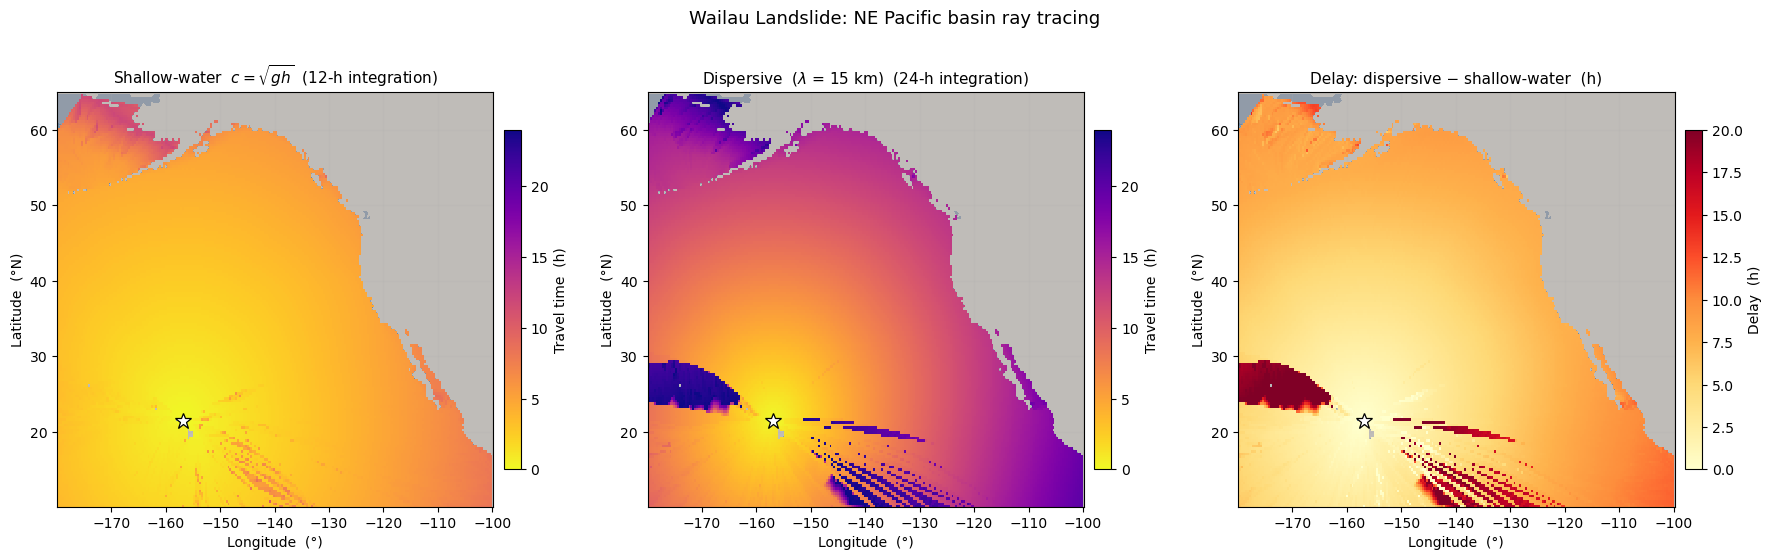

In [8]:
# ── ocean/land mask at bin resolution ────────────────────────────────────────
from scipy.interpolate import RegularGridInterpolator
rgi = RegularGridInterpolator((lon_sub, lat_sub), depth_sub,
                               method='linear', bounds_error=False, fill_value=0.0)
LON_B, LAT_B = np.meshgrid(lon_bin, lat_bin)
depth_bin    = rgi((LON_B, LAT_B))
ocean_depth  = np.where(depth_bin > 0, depth_bin, np.nan)

# ── colour scales (travel time in hours) ──────────────────────────────────────
# Use the same 0–24 h scale for both travel-time panels so wavefront positions
# are directly comparable; dispersive contours sit at roughly twice the hours
# of their shallow-water counterparts.
vmax_tt   = 24.0   # h
vmax_diff = max(float(np.nanpercentile(tt_diff, 98)), 0.1)

fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))

TT_MAPS = [tt_sw, tt_disp, tt_diff]
CMAPS   = ['plasma_r', 'plasma_r', 'YlOrRd']
VMAXS   = [vmax_tt, vmax_tt, vmax_diff]
LABELS  = ['Travel time  (h)', 'Travel time  (h)', 'Delay  (h)']
TITLES  = [
    r'Shallow-water  $c = \sqrt{gh}$  (12-h integration)',
    f'Dispersive  ($\lambda$ = {LAM_WAILAU/1000:.0f} km)  (24-h integration)',
    'Delay: dispersive − shallow-water  (h)',
]

for ax, tt_map, cmap, vmax, title, label in zip(
        axes, TT_MAPS, CMAPS, VMAXS, TITLES, LABELS):

    ax.set_facecolor('#bfbcb8')

    ax.contourf(lon_bin, lat_bin, ocean_depth,
                levels=np.linspace(0, 6000, 13), cmap='Blues_r',
                alpha=0.25, zorder=1)

    pcm = ax.pcolormesh(lon_bin, lat_bin, tt_map,
                        cmap=cmap, vmin=0, vmax=vmax,
                        shading='nearest', zorder=2)
    fig.colorbar(pcm, ax=ax, label=label, pad=0.02, shrink=0.82)

    ax.plot(SRC_LON, SRC_LAT, '*', ms=12, color='white',
            mec='black', mew=0.9, zorder=6)

    ax.set_xlim(lon_bin[0], lon_bin[-1])
    ax.set_ylim(lat_bin[0], lat_bin[-1])
    ax.set_xlabel('Longitude  (°)', fontsize=10)
    ax.set_ylabel('Latitude  (°N)', fontsize=10)
    ax.set_title(title, fontsize=11)
    ax.grid(alpha=0.18)

plt.suptitle("Wailau Landslide: NE Pacific basin ray tracing", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()